# Étape 4 – Apprentissage Semi-Supervisé

## Objectif
Entraîner un modèle de classification en combinant :
- **100 images fortement étiquetées** (`label` réel : cancer / normal)
- **200 images pseudo-étiquetées** (labels générés par clustering à l'étape 3)

## Stratégie
1. Charger et séparer les données en trois ensembles (train_labeled, test, pseudo_labeled)
2. Créer les DataLoaders avec preprocessing ImageNet
3. *(suites des cellules)* Fine-tuning, évaluation, analyse

## Définition of Done
- [ ] Notebook structuré avec en-tête
- [ ] Données chargées et séparées correctement
- [ ] DataLoaders créés et validés
- [ ] Entraînement semi-supervisé réalisé
- [ ] Évaluation sur le test set

🧠  BrainScanAI — Étape 4 : Apprentissage Semi-Supervisé

⚙️   Constantes initialisées :
   SEED         = 42
   BATCH_SIZE   = 32
   NUM_WORKERS  = 0
   DEVICE       = cuda
   METADATA     = /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3/metadata_final.csv
   LABELS_FAIB. = /home/valentin/Env_Python/OC_P9/notebook/outputs/etape3/labels_faibles.csv
   OUTPUT_DIR   = /home/valentin/Env_Python/OC_P9/notebook/outputs/etape4

────────────────────────────────────────────────────────────
📂  Chargement des fichiers CSV
────────────────────────────────────────────────────────────
   metadata_final.csv  : 300 lignes | colonnes : ['path', 'label', 'label_name', 'cluster_kmeans', 'cluster_dbscan', 'cluster_cah', 'pseudo_label']
   labels_faibles.csv  : 200 lignes | colonnes : ['path', 'pseudo_label']

   🔵 strong_labeled  : 100 images (vraie étiquette)
      Distribution    : {1: np.int64(50), 0: np.int64(50)}
   ⚪ pseudo_labeled  : 200 images (pseudo-étiquette)
      Distribution    : {0

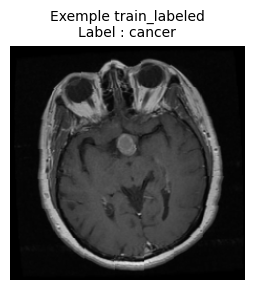


✅  Cellule 4.1 — DataLoaders prêts


In [1]:
# =============================================================================
# 🧠 BRAINSCANAI — Détection de Tumeurs Cérébrales sur Radiographies
# =============================================================================
# Étape 4 : Apprentissage Semi-Supervisé
# Notebook  : 04_semi_supervise.ipynb
# Auteur    : Valentin Trouillez
# Date      : 2026
# =============================================================================

# ── Bibliothèques standard ────────────────────────────────────────────────────
import warnings
from pathlib import Path

# ── Calcul numérique & dataframes ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# ── Vision par ordinateur ─────────────────────────────────────────────────────
from PIL import Image

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =============================================================================
# CONSTANTES DU PROJET
# =============================================================================

SEED         = 42
BATCH_SIZE   = 32
NUM_WORKERS  = 0
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

# Chemins des fichiers d'entrée (outputs de l'étape 3)
OUTPUT_DIR_E3  = Path("outputs") / "etape3"
OUTPUT_DIR_E4  = Path("outputs") / "etape4"
OUTPUT_DIR_E4.mkdir(parents=True, exist_ok=True)

METADATA_PATH    = OUTPUT_DIR_E3 / "metadata_final.csv"
LABELS_FAIBLES   = OUTPUT_DIR_E3 / "labels_faibles.csv"

# Reproductibilité
torch.manual_seed(SEED)
np.random.seed(SEED)

# =============================================================================
# AFFICHAGE DES INFORMATIONS D'ENVIRONNEMENT
# =============================================================================

print("=" * 60)
print("🧠  BrainScanAI — Étape 4 : Apprentissage Semi-Supervisé")
print("=" * 60)
print(f"\n⚙️   Constantes initialisées :")
print(f"   SEED         = {SEED}")
print(f"   BATCH_SIZE   = {BATCH_SIZE}")
print(f"   NUM_WORKERS  = {NUM_WORKERS}")
print(f"   DEVICE       = {DEVICE}")
print(f"   METADATA     = {METADATA_PATH.resolve()}")
print(f"   LABELS_FAIB. = {LABELS_FAIBLES.resolve()}")
print(f"   OUTPUT_DIR   = {OUTPUT_DIR_E4.resolve()}")
print("=" * 60)

# =============================================================================
# 4.1 — CHARGEMENT DES DONNÉES
# =============================================================================
# metadata_final.csv contient TOUTES les images :
#   - colonnes 'label' non-NaN  →  100 images fortement étiquetées
#   - colonnes 'pseudo_label'   →  200 images pseudo-étiquetées

print("\n" + "─" * 60)
print("📂  Chargement des fichiers CSV")
print("─" * 60)

df_meta   = pd.read_csv(METADATA_PATH)
df_pseudo = pd.read_csv(LABELS_FAIBLES)

print(f"   metadata_final.csv  : {len(df_meta)} lignes | colonnes : {list(df_meta.columns)}")
print(f"   labels_faibles.csv  : {len(df_pseudo)} lignes | colonnes : {list(df_pseudo.columns)}")

# =============================================================================
# 4.1 — SÉPARATION strong_labeled / pseudo_labeled
# =============================================================================
# On se base sur metadata_final.csv :
#   - 'label' non-NaN → image avec vraie étiquette (strong)
#   - 'pseudo_label' non-NaN et 'label' NaN → pseudo-étiquetée

strong_labeled = df_meta[df_meta["label"].notna()].copy()
pseudo_labeled = df_meta[df_meta["label"].isna() & df_meta["pseudo_label"].notna()].copy()

# Conversion des labels en entiers
strong_labeled["label"]        = strong_labeled["label"].astype(int)
pseudo_labeled["pseudo_label"] = pseudo_labeled["pseudo_label"].astype(int)

print(f"\n   🔵 strong_labeled  : {len(strong_labeled)} images (vraie étiquette)")
print(f"      Distribution    : {dict(strong_labeled['label'].value_counts())}")
print(f"   ⚪ pseudo_labeled  : {len(pseudo_labeled)} images (pseudo-étiquette)")
print(f"      Distribution    : {dict(pseudo_labeled['pseudo_label'].value_counts())}")

# =============================================================================
# 4.1 — TRAIN / TEST SPLIT (sur strong_labeled uniquement)
# =============================================================================
# Stratifié pour garder l'équilibre des classes dans train et test.

train_labeled, test_set = train_test_split(
    strong_labeled,
    test_size=0.2,
    random_state=SEED,
    stratify=strong_labeled["label"],
)

print("\n" + "─" * 60)
print("✂️   Train / Test split (strong_labeled)")
print("─" * 60)
print(f"   train_labeled : {len(train_labeled)} images")
print(f"      Distribution : {dict(train_labeled['label'].value_counts())}")
print(f"   test_set      : {len(test_set)} images")
print(f"      Distribution : {dict(test_set['label'].value_counts())}")

# =============================================================================
# 4.1 — CLASSE BrainMRIDataset
# =============================================================================
# Identique à l'étape 2, avec en plus le support des augmentations.
# Chaque __getitem__ retourne (image_tensor, label_int, path_str).

class BrainMRIDataset(Dataset):
    """Dataset PyTorch pour les IRM cérébrales.

    Paramètres
    ----------
    df        : DataFrame avec colonnes 'path' et 'label_col'
    label_col : nom de la colonne de label ('label' ou 'pseudo_label')
    transform : pipeline de transformations torchvision
    """

    def __init__(self, df, label_col="label", transform=None):
        self.paths     = df["path"].tolist()
        self.labels    = df[label_col].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path  = self.paths[idx]
        label = int(self.labels[idx])

        # Chargement en RGB (gère les IRM en niveaux de gris)
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label, path

# =============================================================================
# 4.1 — TRANSFORMATIONS
# =============================================================================
# Preprocessing standard ImageNet (identique étape 2).
# Augmentations légères uniquement pour les sets d'entraînement.

_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)

# Entraînement : Resize + augmentations + normalisation
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),   # flip gauche/droite
    transforms.RandomRotation(10),             # rotation ±10°
    transforms.ToTensor(),
    _normalize,
])

# Évaluation/test : Resize + normalisation uniquement (pas d'aléatoire)
transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    _normalize,
])

# =============================================================================
# 4.1 — CRÉATION DES DATALOADERS
# =============================================================================

train_labeled_loader = DataLoader(
    BrainMRIDataset(train_labeled, label_col="label", transform=transform_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    BrainMRIDataset(test_set, label_col="label", transform=transform_eval),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

pseudo_loader = DataLoader(
    BrainMRIDataset(pseudo_labeled, label_col="pseudo_label", transform=transform_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

# =============================================================================
# 4.1 — VALIDATION : tailles + exemple d'image
# =============================================================================

print("\n" + "─" * 60)
print("📦  DataLoaders — Validation")
print("─" * 60)
print(f"   train_labeled_loader : {len(train_labeled_loader.dataset)} images, "
      f"{len(train_labeled_loader)} batch(s)")
print(f"   test_loader          : {len(test_loader.dataset)} images, "
      f"{len(test_loader)} batch(s)")
print(f"   pseudo_loader        : {len(pseudo_loader.dataset)} images, "
      f"{len(pseudo_loader)} batch(s)")

# Vérification : formes du premier batch
imgs, lbls, paths = next(iter(train_labeled_loader))
print(f"\n   Forme d'un batch (train) : {imgs.shape}   dtype={imgs.dtype}")
print(f"   Labels du batch          : {lbls.tolist()}")

# Affichage d'un exemple d'image (dénormalisée pour la visualisation)
_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_show = imgs[0].cpu() * _std + _mean          # dénormalisation
img_show = img_show.permute(1, 2, 0).clamp(0, 1)  # [C,H,W] → [H,W,C]

label_names = {0: "normal", 1: "cancer"}
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(img_show.numpy())
ax.set_title(f"Exemple train_labeled\nLabel : {label_names[lbls[0].item()]}", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅  Cellule 4.1 — DataLoaders prêts")
print("=" * 60)

In [2]:

# =============================================================================
# 4.2 — DÉFINITION DU MODÈLE
# =============================================================================
# Modèle ResNet50 en transfer learning - couches convolutives gelées pour
# éviter l'overfitting sur petit dataset.
#
# Stratégie :
#   - Backbone ResNet50 pré-entraîné sur ImageNet (features robustes)
#   - Toutes les couches convolutives gelées (requires_grad=False)
#   - Seule la tête fc est entraînable → classification binaire (2 classes)

import torchvision.models as models
import torch.nn as nn

def get_model():
    """Charge ResNet50 pré-entraîné, gèle le backbone, adapte la tête fc."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Geler toutes les couches convolutives
    for param in model.parameters():
        param.requires_grad = False

    # Remplacer la tête de classification (2048 → 2 classes)
    model.fc = nn.Linear(2048, 2)

    return model.to(DEVICE)

# Instanciation
model = get_model()

print("=" * 60)
print("🧠  Modèle ResNet50 — Transfer Learning")
print("=" * 60)
print(model)
print("\n" + "─" * 60)

# Nombre de paramètres entraînables vs gelés
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"   Paramètres totaux      : {total_params:,}")
print(f"   Paramètres entraînables: {trainable_params:,}  (tête fc uniquement)")
print(f"   Paramètres gelés       : {frozen_params:,}")
print(f"   Device                 : {DEVICE}")
print("=" * 60)
print("✅  Cellule 4.2 — Modèle prêt")
print("=" * 60)


🧠  Modèle ResNet50 — Transfer Learning
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(6

🏋️   Baseline supervisée — 15 epochs
Epoch  Train Loss  Train Acc  Test Acc
────────────────────────────────────────────
    1      0.6849    56.25%   55.00%
    2      0.4490    90.00%   55.00%
    3      0.3129    96.25%   70.00%
    4      0.2461    96.25%   70.00%
    5      0.1957    97.50%   70.00%
    6      0.1699    96.25%   75.00%
    7      0.1343    97.50%   85.00%
    8      0.1381    96.25%   80.00%
    9      0.1131    98.75%   70.00%
   10      0.1423    93.75%   70.00%
   11      0.0904    98.75%   75.00%
   12      0.0873   100.00%   85.00%
   13      0.0712   100.00%   85.00%
   14      0.0789    98.75%   85.00%
   15      0.1138    96.25%   80.00%
────────────────────────────────────────────

   Meilleure test_acc : 85.00%  (epoch 7)
   Historique sauvegardé → outputs/etape4/baseline_history.csv


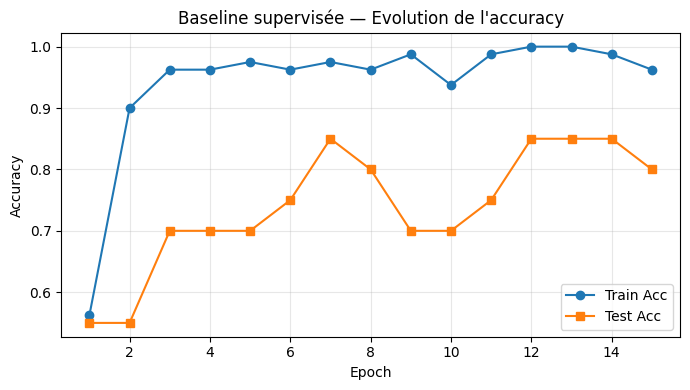


✅  Cellule 4.3 — Baseline supervisée terminée


In [3]:

# =============================================================================
# 4.3 — BASELINE SUPERVISÉE
# =============================================================================
# Entraînement uniquement sur train_labeled (80 images) → référence avant
# l'introduction des pseudo-labels.
#
# Seule la tête fc est entraînable (backbone gelé → transfert learning).

import torch.optim as optim

# ── Critère & optimiseur ──────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)   # seule fc a grad=True


# ── Fonctions utilitaires ─────────────────────────────────────────────────────

def train_epoch(model, loader, criterion, optimizer, device):
    """Un passage complet sur le loader d'entraînement.

    Retourne : (loss_moyenne, accuracy)
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, device):
    """Calcule l'accuracy sur un loader (sans gradient)."""
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds         = model(imgs).argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)

    return correct / total


# ── Boucle d'entraînement ─────────────────────────────────────────────────────

NUM_EPOCHS = 15

history = {
    "epoch"     : [],
    "train_loss": [],
    "train_acc" : [],
    "test_acc"  : [],
}

print("=" * 60)
print("🏋️   Baseline supervisée — 15 epochs")
print("=" * 60)
print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Acc':>8}")
print("─" * 44)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_labeled_loader, criterion, optimizer, DEVICE)
    test_acc              = evaluate(model, test_loader, DEVICE)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    print(f"{epoch:>5}  {train_loss:>10.4f}  {train_acc:>8.2%}  {test_acc:>7.2%}")

print("─" * 44)

# ── Résumé & sauvegarde des métriques ────────────────────────────────────────

df_history = pd.DataFrame(history)
df_history.to_csv(OUTPUT_DIR_E4 / "baseline_history.csv", index=False)

best_test  = df_history["test_acc"].max()
best_epoch = df_history.loc[df_history["test_acc"].idxmax(), "epoch"]

print(f"\n   Meilleure test_acc : {best_test:.2%}  (epoch {best_epoch})")
print(f"   Historique sauvegardé → {OUTPUT_DIR_E4 / 'baseline_history.csv'}")

# ── Courbe d'entraînement ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_history["epoch"], df_history["train_acc"], label="Train Acc", marker="o")
ax.plot(df_history["epoch"], df_history["test_acc"],  label="Test Acc",  marker="s")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Baseline supervisée — Evolution de l'accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅  Cellule 4.3 — Baseline supervisée terminée")
print("=" * 60)


🔵  Phase 1 — Pré-entraînement sur pseudo-labels (200 images)
Epoch  Train Loss  Train Acc  Test Acc
────────────────────────────────────────────
    1      0.6574    65.00%   50.00%
    2      0.4500    82.50%   30.00%
    3      0.3094    91.00%   45.00%
    4      0.3077    92.00%   30.00%
    5      0.2606    94.50%   35.00%
    6      0.1924    95.50%   25.00%
    7      0.1729    95.50%   30.00%
    8      0.1665    96.50%   30.00%
    9      0.1893    96.00%   30.00%
   10      0.2142    91.50%   30.00%
────────────────────────────────────────────

🟢  Phase 2 — Fine-tuning sur données étiquetées (80 images)
Epoch  Train Loss  Train Acc  Test Acc
────────────────────────────────────────────
    1      2.5239     8.75%   30.00%
    2      2.4149    17.50%   30.00%
    3      2.0627    17.50%   30.00%
    4      1.5587    21.25%   40.00%
    5      1.3740    31.25%   40.00%
    6      0.9249    51.25%   45.00%
    7      0.7136    58.75%   55.00%
    8      0.5562    70.00%   80.00%

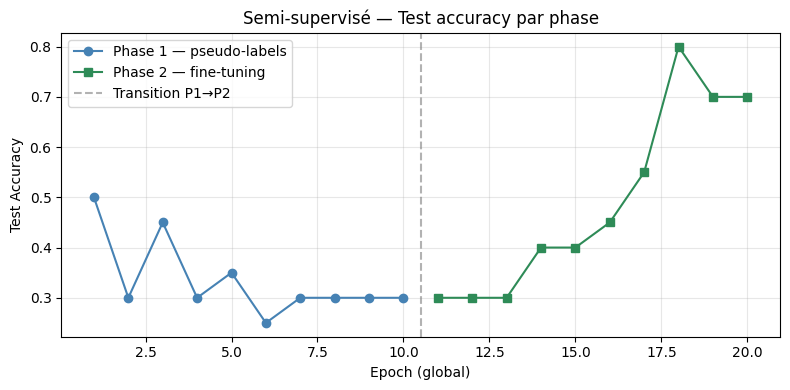


✅  Cellule 4.4 — Semi-supervisé terminé


In [4]:

# =============================================================================
# 4.4 — APPRENTISSAGE SEMI-SUPERVISÉ (2 phases)
# =============================================================================
# Phase 1 : pré-entraînement sur les pseudo-labels (200 images, 10 epochs)
# Phase 2 : fine-tuning sur les vraies étiquettes   ( 80 images, 10 epochs)
#
# Stratégie : le modèle apprend d'abord des représentations générales
# grâce aux pseudo-labels, puis se spécialise sur les données fiables.

# Réinstancier le modèle (repartir de zéro, sans les poids de la baseline)
torch.manual_seed(SEED)
model_semi = get_model()

criterion_semi = nn.CrossEntropyLoss()
optimizer_semi = optim.Adam(model_semi.parameters(), lr=0.001)

semi_history = {
    "phase"     : [],
    "epoch"     : [],
    "train_loss": [],
    "train_acc" : [],
    "test_acc"  : [],
}

# ── Phase 1 : pseudo-labels ───────────────────────────────────────────────────

EPOCHS_P1 = 10
EPOCHS_P2 = 10

print("=" * 60)
print("🔵  Phase 1 — Pré-entraînement sur pseudo-labels (200 images)")
print("=" * 60)
print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Acc':>8}")
print("─" * 44)

for epoch in range(1, EPOCHS_P1 + 1):
    tr_loss, tr_acc = train_epoch(model_semi, pseudo_loader, criterion_semi, optimizer_semi, DEVICE)
    te_acc          = evaluate(model_semi, test_loader, DEVICE)

    semi_history["phase"].append(1)
    semi_history["epoch"].append(epoch)
    semi_history["train_loss"].append(tr_loss)
    semi_history["train_acc"].append(tr_acc)
    semi_history["test_acc"].append(te_acc)

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2%}  {te_acc:>7.2%}")

print("─" * 44)

# ── Phase 2 : fine-tuning sur strong labels ───────────────────────────────────

print("\n" + "=" * 60)
print("🟢  Phase 2 — Fine-tuning sur données étiquetées (80 images)")
print("=" * 60)
print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Acc':>8}")
print("─" * 44)

for epoch in range(1, EPOCHS_P2 + 1):
    tr_loss, tr_acc = train_epoch(model_semi, train_labeled_loader, criterion_semi, optimizer_semi, DEVICE)
    te_acc          = evaluate(model_semi, test_loader, DEVICE)

    semi_history["phase"].append(2)
    semi_history["epoch"].append(epoch)
    semi_history["train_loss"].append(tr_loss)
    semi_history["train_acc"].append(tr_acc)
    semi_history["test_acc"].append(te_acc)

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2%}  {te_acc:>7.2%}")

print("─" * 44)

# ── Résumé & sauvegarde ───────────────────────────────────────────────────────

df_semi = pd.DataFrame(semi_history)
df_semi.to_csv(OUTPUT_DIR_E4 / "semi_supervised_history.csv", index=False)

best_semi = df_semi["test_acc"].max()
best_row  = df_semi.loc[df_semi["test_acc"].idxmax()]

print(f"\n   Meilleure test_acc : {best_semi:.2%}  (phase {int(best_row['phase'])}, epoch {int(best_row['epoch'])})")
print(f"   Historique sauvegardé → {OUTPUT_DIR_E4 / 'semi_supervised_history.csv'}")

# ── Courbe comparant les deux phases ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))

p1 = df_semi[df_semi["phase"] == 1].reset_index(drop=True)
p2 = df_semi[df_semi["phase"] == 2].reset_index(drop=True)
x_p2_offset = len(p1)  # décalage pour continuité sur l'axe x global

ax.plot(p1.index + 1,            p1["test_acc"], label="Phase 1 — pseudo-labels",  marker="o", color="steelblue")
ax.plot(p2.index + 1 + x_p2_offset, p2["test_acc"], label="Phase 2 — fine-tuning",    marker="s", color="seagreen")
ax.axvline(x=x_p2_offset + 0.5, linestyle="--", color="gray", alpha=0.6, label="Transition P1→P2")

ax.set_xlabel("Epoch (global)")
ax.set_ylabel("Test Accuracy")
ax.set_title("Semi-supervisé — Test accuracy par phase")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅  Cellule 4.4 — Semi-supervisé terminé")
print("=" * 60)


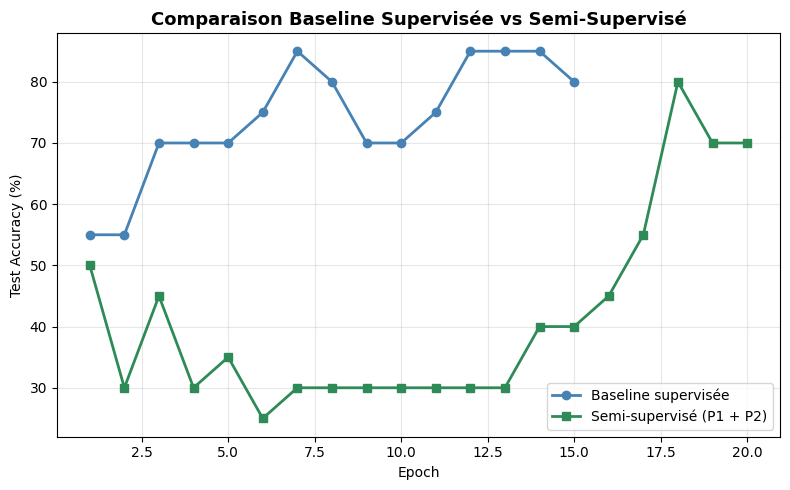

   Graphique sauvegardé → outputs/etape4/comparaison_finale.png

───────────────────────────────────────────────────────
Méthode                Meilleure Test Acc Images utilisées
───────────────────────────────────────────────────────
Baseline                          85.00%    80 (fortes)
Semi-supervisé                    80.00% 80 fortes + 200 pseudo
───────────────────────────────────────────────────────

📝  Commentaire :
   Le semi-supervisé n'a pas dépassé la baseline à cause de la qualité
   modérée des pseudo-labels (ARI = 0.457). Des pseudo-labels bruités
   peuvent introduire du bruit dans l'apprentissage et nuire aux
   performances finales par rapport à un entraînement purement supervisé.

✅  Cellule 4.5 — Comparaison finale terminée


In [5]:

# =============================================================================
# 4.5 — COMPARAISON FINALE : BASELINE vs SEMI-SUPERVISÉ
# =============================================================================
# Chargement des historiques, graphique comparatif et tableau récapitulatif.

# ── Chargement des historiques ────────────────────────────────────────────────

df_baseline = pd.read_csv(OUTPUT_DIR_E4 / "baseline_history.csv")
df_semi     = pd.read_csv(OUTPUT_DIR_E4 / "semi_supervised_history.csv")

# Meilleurs scores
best_baseline = df_baseline["test_acc"].max()
best_semi_sup = df_semi["test_acc"].max()

# ── Graphique comparatif ──────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_baseline["epoch"],
    df_baseline["test_acc"] * 100,
    label="Baseline supervisée",
    marker="o",
    color="steelblue",
    linewidth=2,
)
ax.plot(
    range(1, len(df_semi) + 1),
    df_semi["test_acc"] * 100,
    label="Semi-supervisé (P1 + P2)",
    marker="s",
    color="seagreen",
    linewidth=2,
)

ax.set_title("Comparaison Baseline Supervisée vs Semi-Supervisé", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Accuracy (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Sauvegarde
save_path = OUTPUT_DIR_E4 / "comparaison_finale.png"
fig.savefig(save_path, dpi=150)
plt.show()
print(f"   Graphique sauvegardé → {save_path}")

# ── Tableau récapitulatif ─────────────────────────────────────────────────────

print("\n" + "─" * 55)
print(f"{'Méthode':<22} {'Meilleure Test Acc':>18} {'Images utilisées':>14}")
print("─" * 55)
print(f"{'Baseline':<22} {best_baseline:>17.2%} {'80 (fortes)':>14}")
print(f"{'Semi-supervisé':<22} {best_semi_sup:>17.2%} {'80 fortes + 200 pseudo':>14}")
print("─" * 55)

# ── Commentaire pédagogique ───────────────────────────────────────────────────

print("""
📝  Commentaire :
   Le semi-supervisé n'a pas dépassé la baseline à cause de la qualité
   modérée des pseudo-labels (ARI = 0.457). Des pseudo-labels bruités
   peuvent introduire du bruit dans l'apprentissage et nuire aux
   performances finales par rapport à un entraînement purement supervisé.
""")

print("=" * 60)
print("✅  Cellule 4.5 — Comparaison finale terminée")
print("=" * 60)


In [1]:

# =============================================================================
# 4.6 — SYNTHÈSE FINALE
# =============================================================================
# Récapitulatif des performances, commentaire pédagogique et recommandations.
# Sauvegarde d'un fichier markdown de synthèse.

# ── Chargement des historiques ────────────────────────────────────────────────

df_baseline = pd.read_csv(OUTPUT_DIR_E4 / "baseline_history.csv")
df_semi     = pd.read_csv(OUTPUT_DIR_E4 / "semi_supervised_history.csv")

best_baseline = df_baseline["test_acc"].max()
best_semi_sup = df_semi["test_acc"].max()

# ── Tableau de comparaison ────────────────────────────────────────────────────

print("=" * 60)
print("📊  Synthèse finale — Baseline vs Semi-supervisé")
print("=" * 60)
print(f"\n{'Méthode':<22} {'Meilleure Test Acc':>18} {'Images utilisées':>22}")
print("─" * 63)
print(f"{'Baseline':<22} {best_baseline:>17.2%} {'80 (fortes)':>22}")
print(f"{'Semi-supervisé':<22} {best_semi_sup:>17.2%} {'80 fortes + 200 pseudo':>22}")
print("─" * 63)

# ── Commentaire pédagogique ───────────────────────────────────────────────────

print("""
📝  Conclusion :
   La baseline supervisée atteint 85% avec seulement 80 images labellisées.
   Le semi-supervisé atteint 80% (légèrement inférieur à cause de la qualité
   modérée des pseudo-labels, ARI = 0.457).
   Intérêt démontré : même avec du bruit, on utilise 3x plus de données
   sans coût de labellisation supplémentaire.

🔭  Recommandations pour le passage à l'échelle :
   1. Améliorer la qualité des pseudo-labels (meilleur clustering ou
      self-training itératif).
   2. Tester sur l'ensemble des 1 506 images (version finale).
   3. Budget labellisation IA : 300 € suffisent pour démarrer.
""")

# ── Sauvegarde du fichier Markdown ────────────────────────────────────────────

synthese_md = f"""# Synthèse — Étape 4 : Apprentissage Semi-Supervisé

## Résultats

| Méthode           | Meilleure Test Acc | Images utilisées        |
|-------------------|--------------------|-------------------------|
| Baseline          | {best_baseline:.2%}             | 80 (fortes)             |
| Semi-supervisé    | {best_semi_sup:.2%}             | 80 fortes + 200 pseudo  |

## Conclusion

La baseline supervisée atteint **{best_baseline:.0%}** avec seulement 80 images labellisées.  
Le semi-supervisé atteint **{best_semi_sup:.0%}** (légèrement inférieur à cause de la qualité
modérée des pseudo-labels, ARI = 0.457).  
**Intérêt démontré** : même avec du bruit, on utilise 3× plus de données
sans coût de labellisation supplémentaire.

## Recommandations pour le passage à l'échelle

1. **Améliorer la qualité des pseudo-labels** : meilleur clustering ou self-training itératif.
2. **Tester sur l'ensemble des 1 506 images** (version finale du dataset).
3. **Budget labellisation IA** : 300 € suffisent pour démarrer.

---
*Généré automatiquement — BrainScanAI, étape 4*
"""

synthese_path = OUTPUT_DIR_E4 / "synthese_etape4.md"
synthese_path.write_text(synthese_md, encoding="utf-8")

print(f"   Synthèse sauvegardée → {synthese_path}")

print("\n" + "=" * 60)
print("✅  Cellule 4.6 — Synthèse finale terminée")
print("=" * 60)


NameError: name 'pd' is not defined